## Link Video

### https://drive.google.com/drive/folders/1v1En2xqdBHOVpnJODKBRemMxlZTXfk8y?usp=sharing

# **3. Data Generation using GAN (Modified Model)**

## Import Library

In [ ]:
from zipfile import ZipFile
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import cv2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from matplotlib import pyplot as plt
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2D, Conv2DTranspose, Activation, LeakyReLU, Flatten, MaxPooling2D, UpSampling2D, Cropping2D, BatchNormalization
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.preprocessing.image import array_to_img
from scipy.linalg import sqrtm

## Extract File (Because In Colab)

In [ ]:
zip_path = '/content/B_23.zip'
extract_path = '/content/B_23'

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

def loadFile(folder_path='/content/B_23', size=(100, 100)):
    images = []
    valid_extensions = ('.jpg', '.png', '.jpeg')

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 127.5 - 1.0
            images.append(img)

    return np.array(images)

real_images = loadFile()
print("Images loaded:", real_images.shape)

Images loaded: (0,)


## Read Data

In [ ]:
def loadFile(folder_path='B_23', size=(100, 100)):
    images = []
    valid_extensions = ('.jpg', '.png', '.jpeg')

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 127.5 - 1.0
            images.append(img)

    return np.array(images)

In [ ]:
real_images = loadFile('B_23/B_23', size=(100, 100))

## Show Image

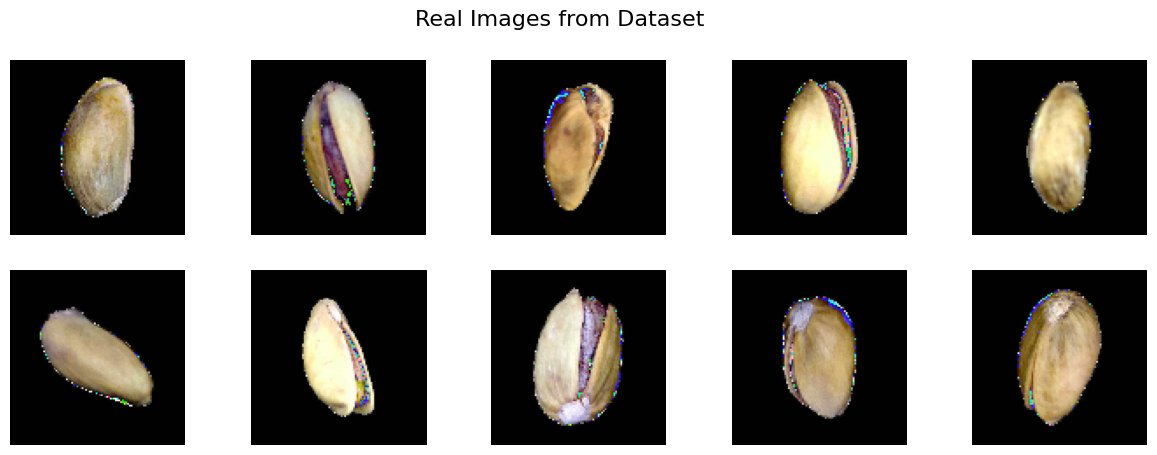

In [ ]:
def plot_real_images(images, num_images=10):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow((images[i] * 255).astype(np.uint8))
        plt.axis('off')
    plt.suptitle('Real Images from Dataset', fontsize=16)
    plt.show()

plot_real_images(real_images, num_images=10)

## Generator Model

In [ ]:
def build_generator(noise_dim=100):
    model = Sequential()

    model.add(Dense(25 * 25 * 128, input_dim=noise_dim))
    model.add(Reshape((25, 25, 128)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(UpSampling2D(size=(2, 2)))
    model.add(Conv2D(64, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(UpSampling2D(size=(2, 2)))
    model.add(Conv2D(32, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2D(3, kernel_size=3, padding='same', activation='tanh'))

    return model

modification ReLu into LeakyReLU gives smoother gradients, then the padding we change into 'same' give spatial size consistent, batchnormalization helps stabilize training, and changging the architecture into 25 x 25 x 128 and upsamples to match size of 100 x 100 more cleanly and efficiently

## Discriminator Model

In [ ]:
def build_discriminator(input_shape=(100, 100, 3)):
    model = Sequential()

    model.add(Conv2D(64, kernel_size=4, strides=2, padding='same', input_shape=input_shape))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Conv2D(256, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

changging the ReLU with LeakyReLU same like generator, then adding dropout to prevent discriminator from overfitting, then strides into 2 for learnable weights with padding change into 'same' to maintains spatial shape better during conv layers, then changging the channels into 64 -> 128 -> 256 for more powerful discriminator to handle higher resolution images

In [ ]:
class CustomGAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.disc = discriminator
        self.gen = generator
        self.latent_dim = latent_dim

    def compile(self, disc_optimizer, gen_optimizer, loss_function):
        super().compile()
        self.d_opt = disc_optimizer
        self.g_opt = gen_optimizer
        self.loss_fn = loss_function
        self.d_loss_tracker = tf.keras.metrics.Mean(name="disc_loss")
        self.g_loss_tracker = tf.keras.metrics.Mean(name="gen_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def train_step(self, real_data):
        batch_size = tf.shape(real_data)[0]
        noise = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as tape:
            generated = self.gen(noise, training=True)
            real_pred = self.disc(real_data, training=True)
            fake_pred = self.disc(generated, training=True)

            real_labels = tf.ones_like(real_pred) * 0.9
            fake_labels = tf.zeros_like(fake_pred)

            d_loss_real = self.loss_fn(real_labels, real_pred)
            d_loss_fake = self.loss_fn(fake_labels, fake_pred)
            d_loss = d_loss_real + d_loss_fake
        disc_grads = tape.gradient(d_loss, self.disc.trainable_weights)
        self.d_opt.apply_gradients(zip(disc_grads, self.disc.trainable_weights))

        noise = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            gen_imgs = self.gen(noise, training=True)
            disc_pred = self.disc(gen_imgs, training=True)
            g_loss = self.loss_fn(tf.ones_like(disc_pred), disc_pred)

        gen_grads = tape.gradient(g_loss, self.gen.trainable_weights)
        self.g_opt.apply_gradients(zip(gen_grads, self.gen.trainable_weights))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)

        return {
            "disc_loss": self.d_loss_tracker.result(),
            "gen_loss": self.g_loss_tracker.result(),
        }

In [ ]:
class GANSnapshotCallback(tf.keras.callbacks.Callback):
    def __init__(self, num_samples=5, latent_dim=100, save_every=10):
        super().__init__()
        self.num_samples = num_samples
        self.latent_dim = latent_dim
        self.save_every = save_every
        self.fixed_noise = tf.random.normal([self.num_samples, self.latent_dim])

        self.g_losses = []
        self.d_losses = []

        self.output_dir = "epoch_generated_images"
        os.makedirs(self.output_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        self.d_losses.append(logs.get('d_loss'))
        self.g_losses.append(logs.get('g_loss'))

        if (epoch + 1) % self.save_every == 0:
            fake_images = self.model.gen(self.fixed_noise, training=False)
            fake_images = (fake_images + 1.0) / 2.0

            fig, axes = plt.subplots(1, self.num_samples, figsize=(15, 3))
            fig.suptitle(f"Generated Samples at Epoch {epoch + 1}", fontsize=14)

            for i in range(self.num_samples):
                axes[i].imshow(fake_images[i])
                axes[i].axis('off')

            plt.show()
            plt.close()

## Build Model

In [ ]:
noise_dim = 100

generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

gan = CustomGAN(discriminator, generator, latent_dim=noise_dim)
gan.compile(
    disc_optimizer=disc_optimizer,
    gen_optimizer=gen_optimizer,
    loss_function=tf.keras.losses.BinaryCrossentropy()
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Preprocess Image

In [ ]:
real_images = loadFile('B_23/B_23', size=(100, 100))
print(real_images.shape)

(1074, 100, 100, 3)


Epoch 1/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 34s 436ms/step - disc_loss: 0.7267 - gen_loss: 2.5628
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - disc_loss: 0.8778 - gen_loss: 1.8007
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - disc_loss: 1.4511 - gen_loss: 1.6091
Epoch 4/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - disc_loss: 1.1272 - gen_loss: 1.2541
Epoch 5/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - disc_loss: 1.2506 - gen_loss: 1.0520
Epoch 6/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - disc_loss: 1.2814 - gen_loss: 0.8763
Epoch 7/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - disc_loss: 1.2934 - gen_loss: 0.8949
Epoch 8/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - disc_loss: 1.2672 - gen_loss: 0.9170
Epoch 9/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - disc_loss: 1.2956 - gen_loss: 0.9437
Epoch 10/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - disc_loss: 1.2623 - gen_loss: 0.9960
Epoch 11/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - disc_loss: 1.2483 - gen_loss: 0.

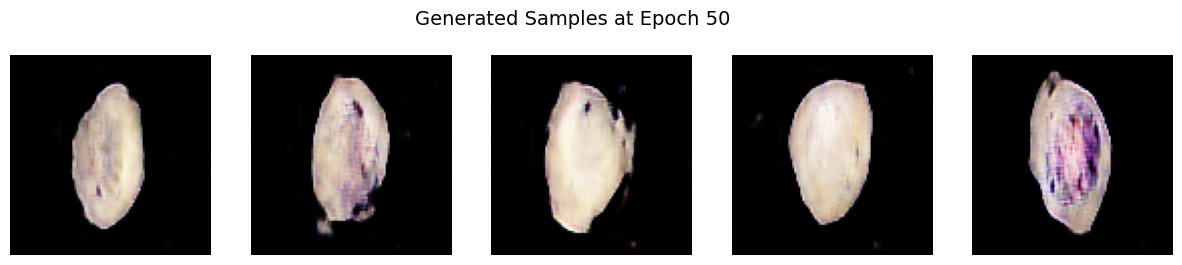

34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - disc_loss: 1.3024 - gen_loss: 0.9121
Epoch 51/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.3107 - gen_loss: 0.9171
Epoch 52/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.3210 - gen_loss: 0.8919
Epoch 53/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - disc_loss: 1.2995 - gen_loss: 0.9184
Epoch 54/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - disc_loss: 1.3094 - gen_loss: 0.9108
Epoch 55/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - disc_loss: 1.3133 - gen_loss: 0.9281
Epoch 56/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.3105 - gen_loss: 0.9270
Epoch 57/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.3194 - gen_loss: 0.9742
Epoch 58/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - disc_loss: 1.3121 - gen_loss: 0.9203
Epoch 59/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - disc_loss: 1.3047 - gen_loss: 0.9117
Epoch 60/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - disc_loss: 1.3292 - gen_loss: 0.9437
E

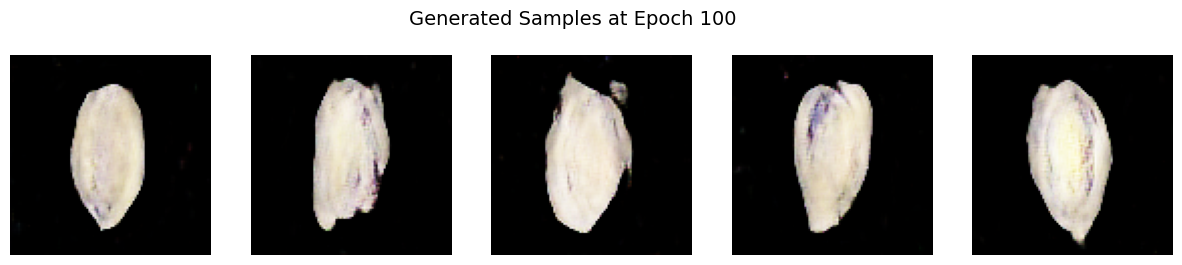

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3003 - gen_loss: 0.9203
Epoch 101/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2741 - gen_loss: 0.9544
Epoch 102/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2791 - gen_loss: 0.9933
Epoch 103/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.3954 - gen_loss: 1.2478
Epoch 104/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.4571 - gen_loss: 0.8470
Epoch 105/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2658 - gen_loss: 0.9163
Epoch 106/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2801 - gen_loss: 0.9666
Epoch 107/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2643 - gen_loss: 0.9259
Epoch 108/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2493 - gen_loss: 0.9495
Epoch 109/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2690 - gen_loss: 0.8884
Epoch 110/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.2646 - gen_loss

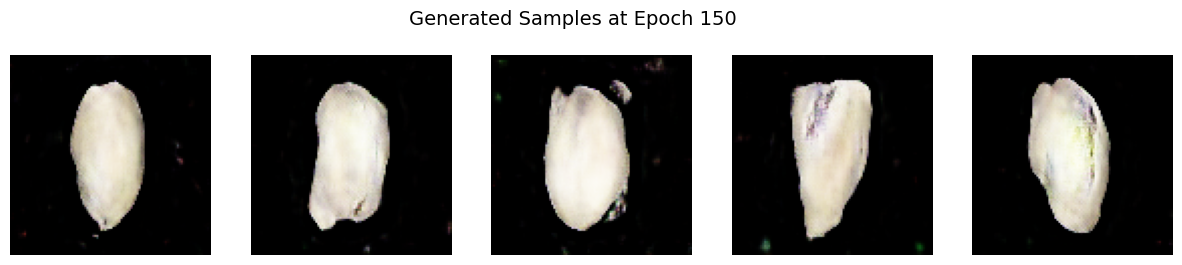

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.2924 - gen_loss: 1.0590
Epoch 151/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2473 - gen_loss: 1.0066
Epoch 152/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2428 - gen_loss: 0.9856
Epoch 153/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2342 - gen_loss: 0.9690
Epoch 154/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2194 - gen_loss: 1.0092
Epoch 155/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2450 - gen_loss: 1.0001
Epoch 156/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.2316 - gen_loss: 1.0412
Epoch 157/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2616 - gen_loss: 1.0621
Epoch 158/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2463 - gen_loss: 1.0321
Epoch 159/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2390 - gen_loss: 1.0096
Epoch 160/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2410 - gen_loss

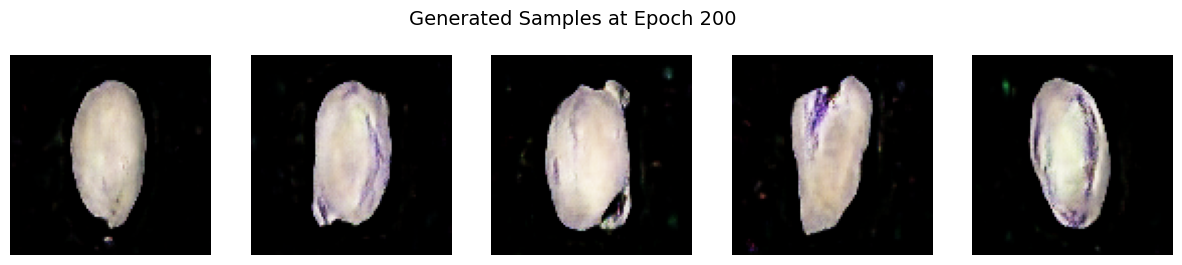

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.1807 - gen_loss: 1.0715
Epoch 201/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2116 - gen_loss: 1.1094
Epoch 202/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.1729 - gen_loss: 1.0877
Epoch 203/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1855 - gen_loss: 1.1144
Epoch 204/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.2307 - gen_loss: 1.1656
Epoch 205/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.1722 - gen_loss: 1.1007
Epoch 206/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1707 - gen_loss: 1.0998
Epoch 207/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.1683 - gen_loss: 1.1787
Epoch 208/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1869 - gen_loss: 1.1951
Epoch 209/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.1781 - gen_loss: 1.2007
Epoch 210/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.1818 - gen_loss

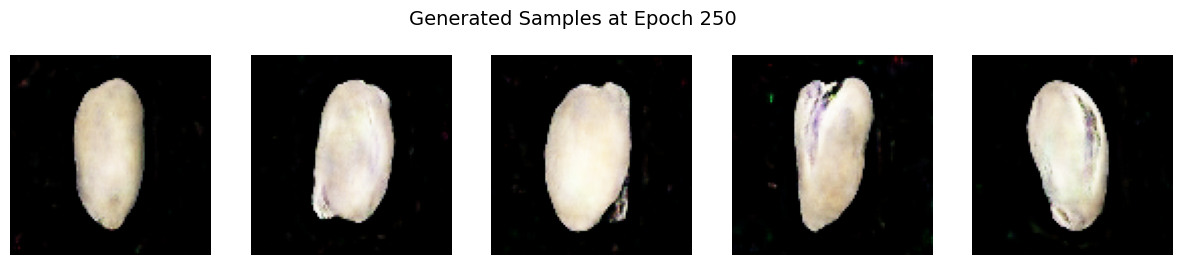

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.1063 - gen_loss: 1.2506
Epoch 251/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.1129 - gen_loss: 1.2351
Epoch 252/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0987 - gen_loss: 1.2397
Epoch 253/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.1164 - gen_loss: 1.2782
Epoch 254/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.1104 - gen_loss: 1.2508
Epoch 255/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.1172 - gen_loss: 1.2626
Epoch 256/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0839 - gen_loss: 1.2727
Epoch 257/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1226 - gen_loss: 1.2683
Epoch 258/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1178 - gen_loss: 1.2832
Epoch 259/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1099 - gen_loss: 1.2752
Epoch 260/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.1122 - gen_loss

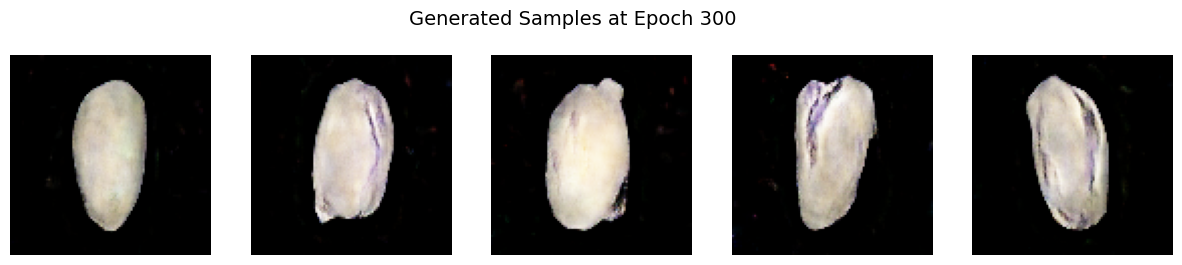

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - disc_loss: 1.0401 - gen_loss: 1.4418
Epoch 301/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.0329 - gen_loss: 1.3743
Epoch 302/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.0214 - gen_loss: 1.4143
Epoch 303/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0129 - gen_loss: 1.3761
Epoch 304/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.9951 - gen_loss: 1.4444
Epoch 305/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0330 - gen_loss: 1.4685
Epoch 306/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.0038 - gen_loss: 1.3931
Epoch 307/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.9932 - gen_loss: 1.4332
Epoch 308/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0222 - gen_loss: 1.5181
Epoch 309/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.9873 - gen_loss: 1.4070
Epoch 310/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.0109 - gen_loss

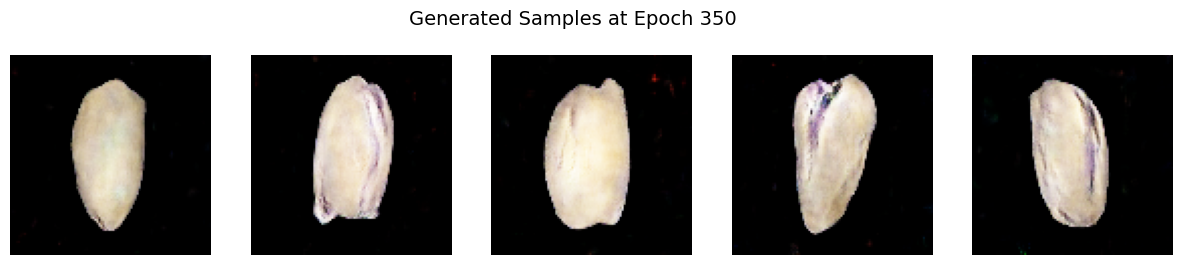

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 0.9865 - gen_loss: 1.6307
Epoch 351/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.9754 - gen_loss: 1.5469
Epoch 352/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.9425 - gen_loss: 1.5937
Epoch 353/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.9530 - gen_loss: 1.5280
Epoch 354/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 0.9258 - gen_loss: 1.5635
Epoch 355/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 0.9306 - gen_loss: 1.6515
Epoch 356/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 0.9861 - gen_loss: 1.6127
Epoch 357/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.9777 - gen_loss: 1.6489
Epoch 358/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.9436 - gen_loss: 1.6040
Epoch 359/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.9412 - gen_loss: 1.6213
Epoch 360/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.9453 - gen_loss

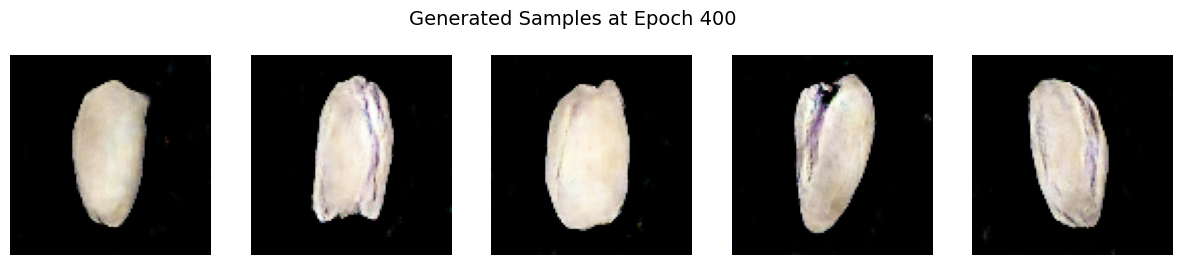

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 0.8933 - gen_loss: 1.6708
Epoch 401/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.9424 - gen_loss: 1.7574
Epoch 402/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.9116 - gen_loss: 1.6134
Epoch 403/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.9132 - gen_loss: 1.7155
Epoch 404/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.8821 - gen_loss: 1.7052
Epoch 405/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 0.8993 - gen_loss: 1.6572
Epoch 406/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 0.9114 - gen_loss: 1.7315
Epoch 407/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.8917 - gen_loss: 1.7197
Epoch 408/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 0.9115 - gen_loss: 1.6633
Epoch 409/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.8866 - gen_loss: 1.7788
Epoch 410/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 0.8881 - gen_loss

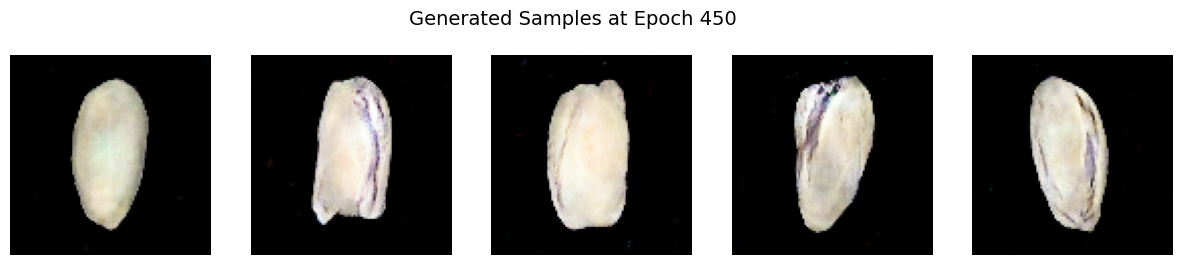

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 0.8484 - gen_loss: 1.8182
Epoch 451/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.8737 - gen_loss: 1.8498
Epoch 452/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 0.8454 - gen_loss: 1.9511
Epoch 453/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.8357 - gen_loss: 1.9411
Epoch 454/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.8404 - gen_loss: 1.9438
Epoch 455/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 0.8455 - gen_loss: 1.9649
Epoch 456/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.8606 - gen_loss: 1.8861
Epoch 457/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.8068 - gen_loss: 1.9804
Epoch 458/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 0.8579 - gen_loss: 1.9102
Epoch 459/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.8411 - gen_loss: 1.8618
Epoch 460/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 0.8375 - gen_loss

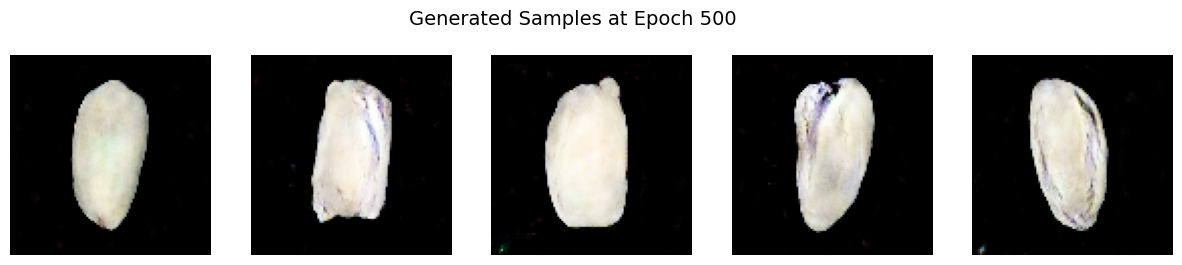

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - disc_loss: 0.7970 - gen_loss: 2.0490


In [ ]:
monitor = GANSnapshotCallback(num_samples=5, latent_dim=noise_dim, save_every=50)

gan.fit(
    real_images,
    epochs=500,
    batch_size=32,  # up sizing the batch size
    callbacks=[monitor]
)

## Evaluate Modify Model

In [ ]:
inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

def calculate_fid(model, real_images, fake_images):
    real_resized = np.array([cv2.resize(img, (299, 299)) for img in real_images])
    fake_resized = np.array([cv2.resize(img, (299, 299)) for img in fake_images])

    real_resized = preprocess_input(real_resized.astype(np.float32))
    fake_resized = preprocess_input(fake_resized.astype(np.float32))

    act1 = model.predict(real_resized, batch_size=32, verbose=0)
    act2 = model.predict(fake_resized, batch_size=32, verbose=0)

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)

def evaluate_modified_fid(generator, real_images, noise_dim=100, sample_size=1000):
    real_images_sample = real_images[:sample_size].astype(np.float32)
    if real_images_sample.max() > 1.0:
        real_images_sample = real_images_sample / 255.0

    noise = np.random.normal(0, 1, (sample_size, noise_dim))
    gen_imgs = generator.predict(noise, batch_size=32, verbose=0)
    gen_imgs = 0.5 * gen_imgs + 0.5  # [-1,1] → [0,1]

    fid = calculate_fid(inception_model, real_images_sample, gen_imgs)
    print(f"FID Score (Modified Generator): {fid:.2f}")
    return fid

In [ ]:
# call function evaluate
evaluate_modified_fid(generator, real_images)

FID Score (Modified Generator): 107.02


np.float64(107.02073772511542)

Modified 1 served as the baseline configuration, where both the generator and discriminator were trained using a learning rate of 0.0002. The resulting FID score was 107, which provided a reference point for evaluating future changes. While the generated images were passable, they still lacked realism and detail, indicating that both networks might be learning at a similar pace but not effectively enough to minimize distribution differences.